# 📘 Module 8.2 — Sensor Fusion & Path Planning

**Goal:** Understand how ADAS systems combine multiple sensors and plan safe paths.

## Sensor Fusion in ADAS

```
Camera  (2D, color, texture)  ─┐
LiDAR   (3D, precise depth)   ─┤──► Fusion ──► Unified 3D Representation
Radar   (velocity, long-range) ─┤
IMU/GPS (ego motion)           ─┘
```

| Sensor | Strengths | Weaknesses |
|--------|-----------|------------|
| **Camera** | Color, texture, signs | No depth, affected by light |
| **LiDAR** | Precise 3D, all weather | Expensive, no color |
| **Radar** | Velocity, long range, weather | Low resolution |

---

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

## 1. BEV (Bird's Eye View) Representation

Modern ADAS projects all sensor data into a **Bird's Eye View** — a top-down representation.

In [2]:
class BEVFusion(nn.Module):
    """Simplified BEV fusion model."""
    
    def __init__(self, bev_size=200, d_model=128):
        super().__init__()
        
        # Camera to BEV (simplified view transform)
        self.camera_to_bev = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=4, padding=3),
            nn.ReLU(),
            nn.Conv2d(64, d_model, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((bev_size // 4, bev_size // 4)),
        )
        
        # LiDAR BEV encoder
        self.lidar_encoder = nn.Sequential(
            nn.Conv2d(5, 64, 3, padding=1),  # 5 channels: x, y, z, intensity, height
            nn.ReLU(),
            nn.Conv2d(64, d_model, 3, padding=1),
            nn.ReLU(),
        )
        
        # Fusion
        self.fusion = nn.Sequential(
            nn.Conv2d(d_model * 2, d_model, 1),  # Concatenate camera + lidar
            nn.ReLU(),
            nn.Conv2d(d_model, d_model, 3, padding=1),
            nn.ReLU(),
        )
        
        # Detection head (BEV object detection)
        self.det_head = nn.Conv2d(d_model, 7, 1)  # 7 = class + x,y,w,h,sin,cos
    
    def forward(self, camera_img, lidar_bev):
        cam_feat = self.camera_to_bev(camera_img)   # (B, d, H', W')
        lid_feat = self.lidar_encoder(lidar_bev)     # (B, d, H', W')
        
        # Match sizes (simplified)
        cam_feat = nn.functional.interpolate(cam_feat, size=lid_feat.shape[2:])
        
        fused = self.fusion(torch.cat([cam_feat, lid_feat], dim=1))
        detections = self.det_head(fused)
        
        return detections

model = BEVFusion(bev_size=200)
cam = torch.randn(1, 3, 480, 640)
lidar = torch.randn(1, 5, 50, 50)  # BEV LiDAR grid

det = model(cam, lidar)
print(f"Camera: {cam.shape}")
print(f"LiDAR BEV: {lidar.shape}")
print(f"BEV Detections: {det.shape}")

Camera: torch.Size([1, 3, 480, 640])
LiDAR BEV: torch.Size([1, 5, 50, 50])
BEV Detections: torch.Size([1, 7, 50, 50])


## 2. Path Planning Visualization

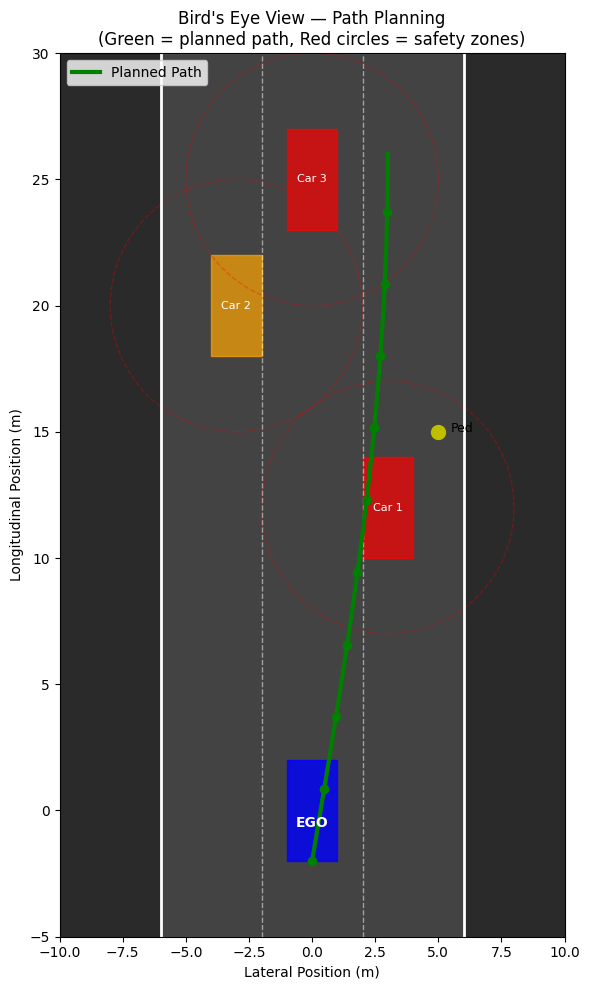

In [3]:
# --- Simulate a driving scene in BEV ---
fig, ax = plt.subplots(figsize=(8, 10))

# Road
ax.fill_between([-6, 6], [-5, -5], [30, 30], color='gray', alpha=0.3)
ax.plot([-2, -2], [-5, 30], 'w--', linewidth=1, alpha=0.5)  # Lane divider
ax.plot([2, 2], [-5, 30], 'w--', linewidth=1, alpha=0.5)
ax.plot([-6, -6], [-5, 30], 'w-', linewidth=2)  # Road edge
ax.plot([6, 6], [-5, 30], 'w-', linewidth=2)

# Ego vehicle
ego = plt.Rectangle((-1, -2), 2, 4, color='blue', alpha=0.8)
ax.add_patch(ego)
ax.text(0, -0.5, 'EGO', ha='center', va='center', color='white', fontweight='bold')

# Other vehicles
obstacles = [
    (3, 12, 'red', 'Car 1'),
    (-3, 20, 'orange', 'Car 2'),
    (0, 25, 'red', 'Car 3'),
]
for x, y, color, label in obstacles:
    rect = plt.Rectangle((x-1, y-2), 2, 4, color=color, alpha=0.7)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', color='white', fontsize=8)

# Pedestrian
ax.plot(5, 15, 'yo', markersize=10)
ax.text(5.5, 15, 'Ped', fontsize=9)

# Planned path (smooth curve)
t = np.linspace(0, 1, 50)
path_x = -0.0 + 3 * np.sin(np.pi * t * 0.5)
path_y = -2 + 28 * t
ax.plot(path_x, path_y, 'g-', linewidth=3, label='Planned Path')
ax.plot(path_x[::5], path_y[::5], 'go', markersize=6)

# Danger zones
for x, y, _, _ in obstacles:
    circle = Circle((x, y), 5, color='red', fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)

ax.set_xlim(-10, 10)
ax.set_ylim(-5, 30)
ax.set_xlabel('Lateral Position (m)')
ax.set_ylabel('Longitudinal Position (m)')
ax.set_title('Bird\'s Eye View — Path Planning\n(Green = planned path, Red circles = safety zones)')
ax.legend(loc='upper left')
ax.set_facecolor('#2a2a2a')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. The Complete ADAS Stack

```
┌─────────────────────────────────────────────────┐
│                 ADAS Software Stack              │
├─────────────────────────────────────────────────┤
│                                                  │
│  SENSORS  →  PERCEPTION  →  PREDICTION  → PLAN  │
│  Camera      Object Det.    Trajectory    Path   │
│  LiDAR       Lane Det.      Intent        Speed  │
│  Radar       Segmentation   Risk          Steer  │
│  IMU/GPS     Tracking                            │
│                                                  │
│  ────────── Deep Learning Models ──────────      │
│  CNNs, Transformers, RNNs, VLMs, VLAs           │
│                                                  │
└─────────────────────────────────────────────────┘
```

In [4]:
print("🎓 Congratulations! You've completed the Deep Learning for ADAS curriculum!")
print("=" * 65)
print()
print("You've learned:")
print("  ✅ Module 1: Foundations — NumPy, PyTorch, Neural Networks")
print("  ✅ Module 2: CNNs — Convolution, ResNet, Object Detection")
print("  ✅ Module 3: RNNs — LSTM, GRU, Sequence Modeling")
print("  ✅ Module 4: Transformers — Attention, ViT, DETR")
print("  ✅ Module 5: LLMs — Tokenization, GPT, Fine-tuning")
print("  ✅ Module 6: VLMs — CLIP, Multimodal Understanding")
print("  ✅ Module 7: VLAs — Vision-Language-Action, E2E Driving")
print("  ✅ Module 8: ADAS — Lane Detection, Sensor Fusion, Planning")
print()
print("📚 Continue learning with the resources in the /resources folder!")
print("🔬 Check out the research papers in resources/PAPERS.md")
print("📖 Dive deeper with the free books in resources/FREE_BOOKS.md")

🎓 Congratulations! You've completed the Deep Learning for ADAS curriculum!

You've learned:
  ✅ Module 1: Foundations — NumPy, PyTorch, Neural Networks
  ✅ Module 2: CNNs — Convolution, ResNet, Object Detection
  ✅ Module 3: RNNs — LSTM, GRU, Sequence Modeling
  ✅ Module 4: Transformers — Attention, ViT, DETR
  ✅ Module 5: LLMs — Tokenization, GPT, Fine-tuning
  ✅ Module 6: VLMs — CLIP, Multimodal Understanding
  ✅ Module 7: VLAs — Vision-Language-Action, E2E Driving
  ✅ Module 8: ADAS — Lane Detection, Sensor Fusion, Planning

📚 Continue learning with the resources in the /resources folder!
🔬 Check out the research papers in resources/PAPERS.md
📖 Dive deeper with the free books in resources/FREE_BOOKS.md


---
## ✅ Final Key Takeaways

1. **Sensor fusion** combines camera + LiDAR + radar for robust perception
2. **BEV representation** provides a unified top-down view for planning
3. **Path planning** considers obstacles, traffic rules, and comfort
4. The ADAS stack is evolving from **modular** to **end-to-end** approaches
5. Deep learning is the core technology powering modern ADAS systems

---
## 📚 Where to Go From Here

1. **Practice:** Try the datasets in [resources/DATASETS.md](../resources/DATASETS.md)
2. **Read:** Study the papers in [resources/PAPERS.md](../resources/PAPERS.md)
3. **Build:** Implement a full detection pipeline on KITTI or nuScenes
4. **Simulate:** Use CARLA simulator for end-to-end driving experiments
5. **Contribute:** Join open-source ADAS projects on GitHub